<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/LongTermInvesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 103.5 MB/s eta 0:00:00
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.14.0
    Uninstalling curl_cffi-0.14.0:
      Successfully uninstalled curl_cffi-0.14.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [2]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import linregress
print("Libraries Installed!")

1.1.0
Libraries Installed!


In [3]:
df_raw = pd.read_csv('longterm.csv')

# Example usage
tickers = df_raw['Asset'].to_list()
print(len(tickers))
#ranked_picks = tickers

19


# Classify Sector Stages

In [4]:

def weinstein_stage(df, sma_window=30):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(sma_window), df["SMA"].tail(sma_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma = df["SMA"].iloc[-1]

    # Determine stage
    if latest_price > latest_sma and slope > 0:
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif latest_price < latest_sma and slope > 0:
        stage = "Stage 1 (Basing)"
    elif latest_price > latest_sma and slope < 0:
        stage = "Stage 3 (Topping)"
    else:
        stage = "Transition"

    return stage, slope, latest_price, latest_sma


In [5]:
# Classify stocks into stages
results = []
for etf in tickers:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma = stage_info
        results.append({
            "Asset": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)
stages_df.head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BREA"}}}
ERROR:yfinance:$BREA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BREA']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*******

,Asset,Stage,SMA_Slope,Latest_Price,30W_SMA
3,BAB.L,Stage 2 (Advancing),14.995920,1429.000000,1187.354150
8,GS,Stage 2 (Advancing),7.584904,935.409973,802.376980
17,BLK,Stage 2 (Advancing),5.404547,1118.939941,1102.654942
0,SPY,Stage 2 (Advancing),3.195080,691.969971,662.163859
5,LHX,Stage 2 (Advancing),2.438696,342.850006,289.568742


In [6]:
advancing_stocks= stages_df[stages_df["Stage"] .isin(["Stage 2 (Advancing)","Stage 1 (Basing)"]) ]
advancing_stocks.reset_index(drop=True, inplace=True)
advancing_stocks.head()

,Asset,Stage,SMA_Slope,Latest_Price,30W_SMA
0,BAB.L,Stage 2 (Advancing),14.995920,1429.000000,1187.354150
1,GS,Stage 2 (Advancing),7.584904,935.409973,802.376980
2,BLK,Stage 2 (Advancing),5.404547,1118.939941,1102.654942
3,SPY,Stage 2 (Advancing),3.195080,691.969971,662.163859
4,LHX,Stage 2 (Advancing),2.438696,342.850006,289.568742


In [7]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  18 of 18 completed


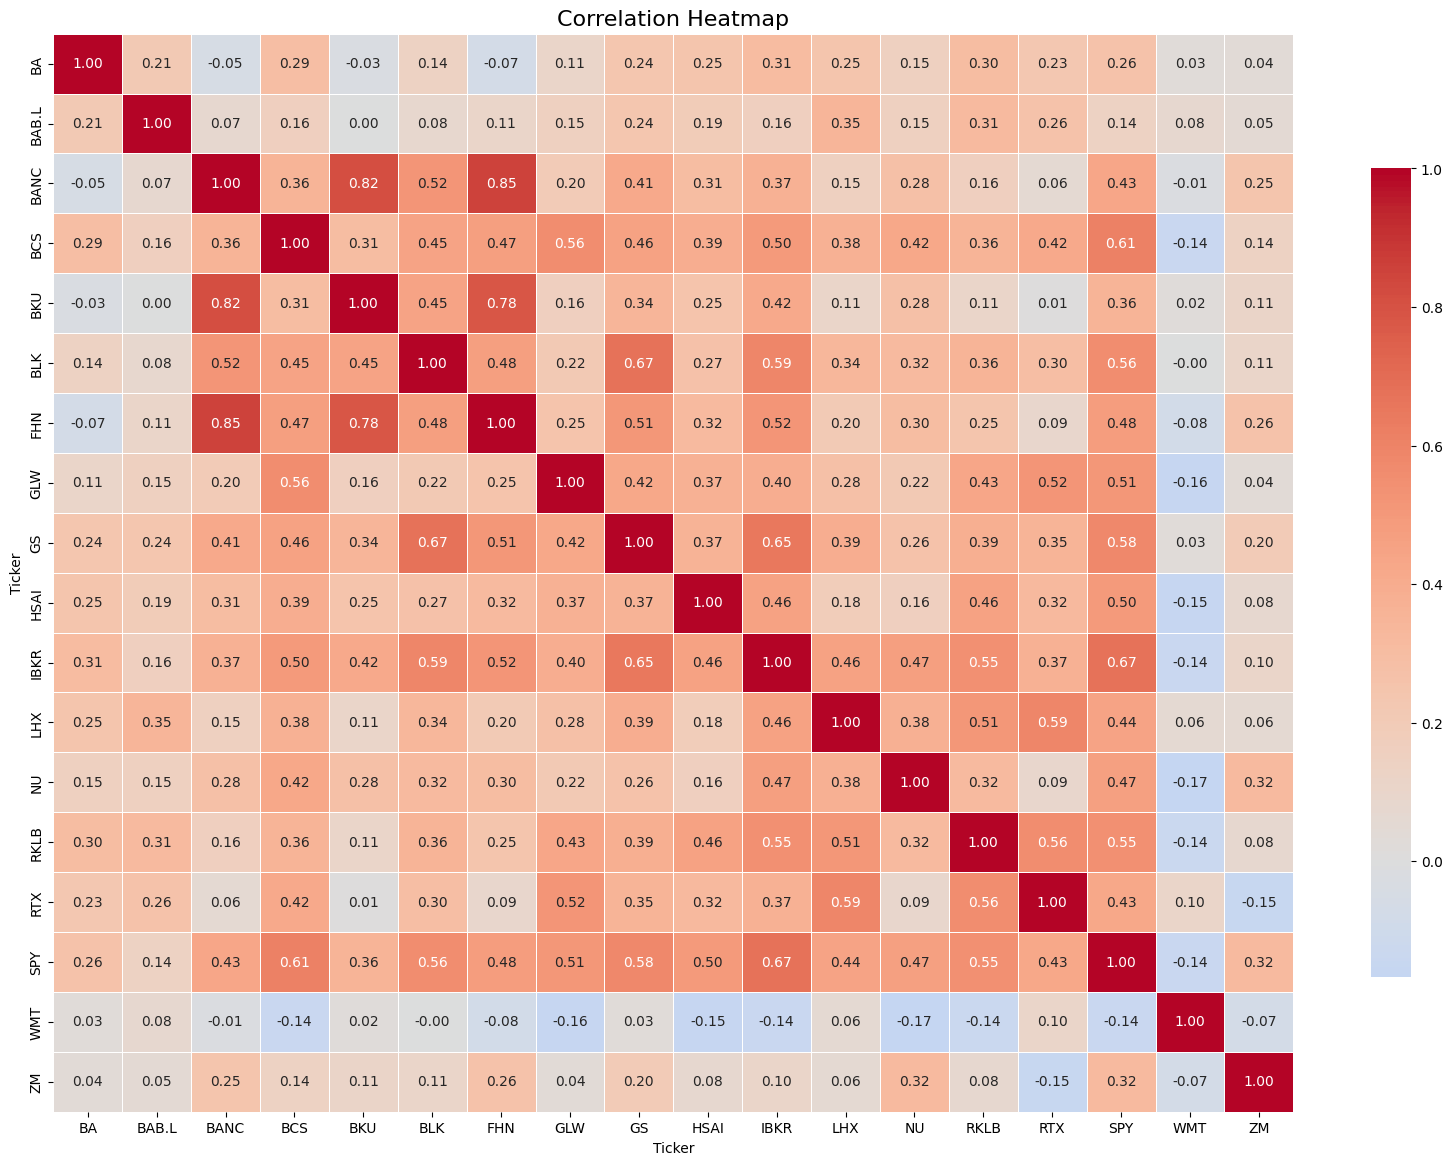

In [8]:

# Example usage
tickers = advancing_stocks['Asset'].to_list()
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(20, 14))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [9]:

#print("Final uncorrelated picks:", final_selection)
#print("\nCorrelation matrix:\n", corr_matrix)

# Keep only rows where Asset is in filtered
filtered_list = advancing_stocks[advancing_stocks["Asset"].isin(final_selection)]

buy_list = filtered_list.copy()
buy_list.head()

,Asset,Stage,SMA_Slope,Latest_Price,30W_SMA
0,BAB.L,Stage 2 (Advancing),14.995920,1429.000000,1187.354150
1,GS,Stage 2 (Advancing),7.584904,935.409973,802.376980
3,SPY,Stage 2 (Advancing),3.195080,691.969971,662.163859
4,LHX,Stage 2 (Advancing),2.438696,342.850006,289.568742
5,RTX,Stage 2 (Advancing),1.395216,200.929993,169.401407


In [10]:
def money_flow_signals(df, period=10):
    """
    Calculate Money Flow Index (MFI) and generate signals:
    - Positive money flow (TP > TP_prev)
    - Divergence (Price vs MFI mismatch)

    Parameters:
        df (pd.DataFrame): DataFrame with columns ["High", "Low", "Close", "Volume"]
        period (int): Lookback period for MFI (default=10)

    Returns:
        pd.DataFrame with added columns: ["TypicalPrice", "MFI", "PositiveFlow", "Divergence"]
    """

    df = df.copy()

    # Step 1: Typical Price
    df["TypicalPrice"] = (df["High"] + df["Low"] + df["Close"]) / 3

    # Step 2: Raw Money Flow
    df["RawMoneyFlow"] = df["TypicalPrice"] * df["Volume"]

    # Step 3: Positive & Negative Flow
    df["PositiveFlow"] = np.where(df["TypicalPrice"] > df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)
    df["NegativeFlow"] = np.where(df["TypicalPrice"] < df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)

    # Step 4: Money Flow Ratio & MFI
    pos_flow = df["PositiveFlow"].rolling(period).sum()
    neg_flow = df["NegativeFlow"].rolling(period).sum()
    money_flow_ratio = pos_flow / neg_flow.replace(0, np.nan)
    df["MFI"] = 100 - (100 / (1 + money_flow_ratio))

    # Step 5: Positive Money Flow Signal
    df["PositiveFlowSignal"] = df["TypicalPrice"] > df["TypicalPrice"].shift(1)

    # Step 6: Divergence Detection
    df["PriceHigh"] = df["Close"].rolling(period).max()
    df["PriceLow"] = df["Close"].rolling(period).min()
    df["MFIHigh"] = df["MFI"].rolling(period).max()
    df["MFILow"] = df["MFI"].rolling(period).min()

    def divergence(row):
        if np.isnan(row["MFI"]):
            return None
        # Price makes higher high, but MFI does not
        if row["Close"] >= row["PriceHigh"] and row["MFI"] < row["MFIHigh"]:
            return "Bearish Divergence ⚠️"
        # Price makes lower low, but MFI does not
        elif row["Close"] <= row["PriceLow"] and row["MFI"] > row["MFILow"]:
            return "Bullish Divergence ✅"
        else:
            return "No Divergence"

    df["Divergence"] = df.apply(divergence, axis=1)
    df['Entry_signal']= (df["MFI"] > 50) & (df["Divergence"] == "No Divergence")
    curr = df.iloc[-1]

    return curr.Entry_signal

In [11]:
def check_entry_conditions(tickers):
    results = []
    for ticker in tickers:
      df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
      if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first leve
      mfi_signal = money_flow_signals(df)
      # Print results
      print(f"\nMoney flow indicator for {ticker} is:")
      print(mfi_signal)

      refined_entry_signal = mfi_signal


      if mfi_signal :
        entry_signal = "Entry"
      else:
        entry_signal = "Bearish"
      results.append([ticker, entry_signal])
    # Convert results to DataFrame
    df_results = pd.DataFrame(results, columns=["Asset", "Entry_Signal"])
    return df_results


In [12]:
final_etfs_to_check = buy_list['Asset'].to_list()
buy_lists = check_entry_conditions(final_etfs_to_check)
#df = buy_lists[buy_lists['Entry_Signal'] =="Entry"]
df = buy_lists.copy()
#df.reset_index(drop=True, inplace=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Money flow indicator for BAB.L is:
False

Money flow indicator for GS is:
True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Money flow indicator for SPY is:
True



Money flow indicator for LHX is:
True


...


Money flow indicator for GLW is:
True

Money flow indicator for RKLB is:
False


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Money flow indicator for WMT is:
False

Money flow indicator for HSAI is:
False

Money flow indicator for BCS is:
True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Money flow indicator for BKU is:
True

Money flow indicator for ZM is:
True

Money flow indicator for NU is:
True


In [13]:
df

,Asset,Entry_Signal
0,BAB.L,Bearish
1,GS,Entry
2,SPY,Entry
3,LHX,Entry
4,RTX,Bearish
5,BA,Bearish
6,GLW,Entry
7,RKLB,Bearish
8,WMT,Bearish
9,HSAI,Bearish


# Compute Mansfield Relative Strength (MRS)

In [14]:

def compute_mansfield_rs(asset_df, benchmark_df, window):
    """Compute Mansfield Relative Strength (MRS) vs a benchmark."""
    # Handle MultiIndex columns
    if isinstance(asset_df.columns, pd.MultiIndex):
        asset_df.columns = asset_df.columns.get_level_values(0)
    if isinstance(benchmark_df.columns, pd.MultiIndex):
        benchmark_df.columns = benchmark_df.columns.get_level_values(0)

    # Align and clean data
    data = pd.DataFrame({
        "Asset": asset_df["Close"],
        "Benchmark": benchmark_df["Close"]
    }).reindex(asset_df.index.union(benchmark_df.index)).ffill().dropna()

    if len(data) < window:
        return None  # not enough data

    data["RS"] = data["Asset"] / data["Benchmark"]
    data["RS_MA"] = data["RS"].rolling(window=window, min_periods=window).mean()
    data["MRS"] = ((data["RS"] / data["RS_MA"]) - 1) * 100

    return data["MRS"].iloc[-1]  # latest MRS value


In [15]:

# ETF universe
etfs = df['Asset'].to_list()

# Benchmark
benchmark = yf.download("SPY", period="6mo", interval="1wk", auto_adjust=True)

# ---------- STAGE 1: 3-MONTH MRS (12 weeks) ----------
mrs_3m = {}
for etf in etfs:
    data = yf.download(etf, period="2y", interval="1wk", auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=12)
    if mrs_value is not None:
        mrs_3m[etf] = mrs_value

mrs_3m_df = pd.DataFrame(list(mrs_3m.items()), columns=["ETF", "MRS_3M"])
mrs_3m_df = mrs_3m_df[mrs_3m_df["MRS_3M"] >= 0].sort_values(by="MRS_3M", ascending=False)
print("\n✅ 3-Month Positive MRS ETFs:")
mrs_3m_df.reset_index(drop=True, inplace=True)
mrs_3m_df


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


✅ 3-Month Positive MRS ETFs:


,ETF,MRS_3M
0,RKLB,17.970227
1,GLW,14.942631
2,LHX,10.437882
3,BAB.L,9.427792
4,RTX,7.653315
5,BCS,7.640483
6,BA,6.683428
7,ZM,5.832413
8,BKU,4.995607
9,GS,4.648932


In [16]:
# ---------- STAGE 2: 1-MONTH MRS (4 weeks) ----------
selected_etfs = mrs_3m_df["ETF"].tolist()
mrs_1m = {}
for etf in selected_etfs:
    data = yf.download(etf, period="3mo", interval="1wk",auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=4)
    if mrs_value is not None:
        mrs_1m[etf] = mrs_value

mrs_1m_df = pd.DataFrame(list(mrs_1m.items()), columns=["ETF", "MRS_1M"]).sort_values(by="MRS_1M", ascending=False)
mrs_1m_df = mrs_1m_df[mrs_1m_df["MRS_1M"] >= 0].sort_values(by="MRS_1M", ascending=False)
print("\n🔥 1-Month MRS Ranking Among 3M Positive ETFs:")
mrs_1m_df.reset_index(drop=True, inplace=True)
mrs_1m_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



🔥 1-Month MRS Ranking Among 3M Positive ETFs:


,ETF,MRS_1M
0,GLW,9.800929
1,ZM,7.049589
2,RTX,2.049435
3,BCS,1.791009
4,NU,1.608086
5,BKU,1.352476
6,WMT,1.121395
7,SPY,0.000000


In [17]:


def calculate_atr(df, period=60):
    """Calculate the Average True Range (ATR)."""
    high = df['High']
    low = df['Low']
    close = df['Close']

    tr1 = high - low
    tr2 = abs(high - close.shift(1))
    tr3 = abs(low - close.shift(1))

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window=period).mean()
    return atr

def add_monthly_atr(data, atr_period=60):
    """
    Given a DataFrame with column 'ETF' (tickers),
    fetch 1-month daily data and compute 1M ATR for each.
    """
    atr_values = []

    for ticker in data['ETF']:
        try:
            df = yf.download(ticker, period="3mo", interval="1d", progress=False,auto_adjust=True)
            if len(df) < atr_period:
                atr_values.append(np.nan)
                continue

            df['ATR'] = calculate_atr(df, period=atr_period)
            latest_atr = df['ATR'].iloc[-1]
            atr_values.append(latest_atr)

        except Exception as e:
            print(f"Error fetching {ticker}: {e}")
            atr_values.append(np.nan)

    data['ATR_1M'] = atr_values
    return data

# --- Example usage ---
# Suppose your starting DataFrame looks like this:
etf_df = pd.DataFrame({
    'ETF': mrs_1m_df.ETF.to_list()
})

df = add_monthly_atr(etf_df)
df


,ETF,ATR_1M
0,GLW,3.597424
1,ZM,2.622716
2,RTX,3.844456
3,BCS,0.433667
4,NU,0.511100
5,BKU,1.115604
6,WMT,2.202721
7,SPY,7.088640
